# Global Wheat Head: Domain Ranking by AP (Train Only)

This notebook does one thing:
- rank each domain by detection AP on the **train split only**.

Inputs:
- raw dataset root (for domain mapping)
- YOLO train images/labels
- trained model weight (`best.pt`)

Output:
- table and bar chart: domain -> AP, AP50, AP75 (higher is better)

In [15]:
from __future__ import annotations

import json
import sys
import tempfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from ultralytics import YOLO

PROJECT_ROOT = Path('/home/khanh/Projects/DifficultyAgri')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dagri.baseline.utils import create_coco_gt_json_from_yolo

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

RAW_DATA_ROOT = PROJECT_ROOT / 'datasets/global_wheat_head/raw'
YOLO_DATA_ROOT = PROJECT_ROOT / 'datasets/global_wheat_head/yolo_format/global_wheat_head_yolo'
TRAIN_IMAGES_DIR = YOLO_DATA_ROOT / 'train' / 'images'
TRAIN_LABELS_DIR = YOLO_DATA_ROOT / 'train' / 'labels'
WEIGHT_PATH = PROJECT_ROOT / '.cache_result/global_wheat_head/baseline_model_weight/seed_123/best.pt'

print(f'RAW exists:   {RAW_DATA_ROOT.exists()}')
print(f'TRAIN exists: {TRAIN_IMAGES_DIR.exists()} | labels: {TRAIN_LABELS_DIR.exists()}')
print(f'WEIGHT exists:{WEIGHT_PATH.exists()}')


def build_image_domain_map(raw_root: Path) -> pd.DataFrame:
    rows = []
    for domain_dir in sorted([p for p in raw_root.iterdir() if p.is_dir()]):
        if domain_dir.name == 'labels_extracted':
            continue
        for ext in ('*.png', '*.jpg', '*.jpeg'):
            for img in domain_dir.glob(ext):
                rows.append({'image_name': img.name, 'domain': domain_dir.name})
    return pd.DataFrame(rows).drop_duplicates(subset=['image_name']).reset_index(drop=True)


def evaluate_coco(gt_json_path: Path, dt_json_path: Path) -> dict:
    coco_gt = COCO(str(gt_json_path))
    with open(dt_json_path, 'r', encoding='utf-8') as f:
        dt_list = json.load(f)

    if len(dt_list) == 0:
        return {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0}

    coco_dt = coco_gt.loadRes(str(dt_json_path))
    evaluator = COCOeval(coco_gt, coco_dt, iouType='bbox')
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()

    stats = evaluator.stats
    return {'AP': float(stats[0]), 'AP50': float(stats[1]), 'AP75': float(stats[2])}

RAW exists:   True
TRAIN exists: True | labels: True
WEIGHT exists:True


## Run Train Predictions and Compute AP per Domain

Domain map rows: 4,698
Domains: ['arvalis_1', 'arvalis_2', 'arvalis_3', 'ethz_1', 'inrae_1', 'nau_1', 'rres_1', 'uq_1', 'usask_1', 'utokyo_1', 'utokyo_2']
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Predicted images: 2,700
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.26s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=6.08s).
Accumulating evaluation results...
D

,domain,n_images,AP,AP50,AP75
0,rres_1,363,0.572367,0.961696,0.655646
1,ethz_1,592,0.549914,0.940363,0.593637
2,inrae_1,146,0.522537,0.954434,0.524250
3,arvalis_3,457,0.466389,0.918228,0.403859
4,usask_1,153,0.408026,0.873679,0.311920
5,arvalis_1,827,0.402601,0.889762,0.276476
6,arvalis_2,162,0.365402,0.812967,0.246503


/tmp/ipykernel_941005/519537833.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=domain_ap_df, x='domain', y='AP', palette='viridis')


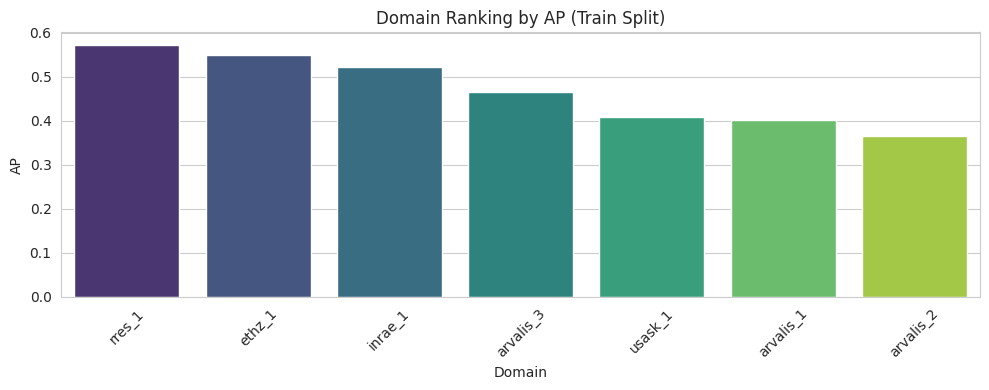

Saved ranking CSV: /home/khanh/Projects/DifficultyAgri/notebooks/global_wheat_head_train_domain_ap_ranking.csv


In [ ]:
domain_map_df = build_image_domain_map(RAW_DATA_ROOT)
print(f'Domain map rows: {len(domain_map_df):,}')
print(f'Domains: {sorted(domain_map_df.domain.unique())}')

auto_conf = 0.25
auto_iou = 0.5
max_det = 300

model = YOLO(str(WEIGHT_PATH))
results = model.predict(
    source=str(TRAIN_IMAGES_DIR),
    conf=auto_conf,
    iou=auto_iou,
    max_det=max_det,
    save=False,
    verbose=False,
)

print(f'Predicted images: {len(results):,}')

with tempfile.TemporaryDirectory(prefix='train_domain_ap_') as tmp:
    tmp = Path(tmp)
    gt_json = tmp / 'train_gt.json'
    dt_json = tmp / 'train_dt.json'

    create_coco_gt_json_from_yolo(
        images_dir=str(TRAIN_IMAGES_DIR),
        labels_dir=str(TRAIN_LABELS_DIR),
        output_json_path=str(gt_json),
        class_names=['wheat_head'],
    )

    # Build detection JSON in COCO format
    detections = []
    for res in results:
        image_id = Path(res.path).stem
        boxes = res.boxes
        if boxes is None or len(boxes) == 0:
            continue

        xyxy = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()
        classes = boxes.cls.cpu().numpy().astype(int)

        for b, c, s in zip(xyxy, classes, confs):
            x1, y1, x2, y2 = map(float, b)
            w = max(0.0, x2 - x1)
            h = max(0.0, y2 - y1)
            detections.append(
                {
                    'image_id': image_id,
                    'category_id': int(c) + 1,
                    'bbox': [x1, y1, w, h],
                    'score': float(s),
                }
            )

    with open(dt_json, 'w', encoding='utf-8') as f:
        json.dump(detections, f)

    # Load GT and attach domain by image file
    with open(gt_json, 'r', encoding='utf-8') as f:
        gt_data = json.load(f)

    image_df = pd.DataFrame(gt_data['images'])[['id', 'file_name']].rename(columns={'id': 'image_id', 'file_name': 'image_name'})
    image_df = image_df.merge(domain_map_df, on='image_name', how='left')

    # Evaluate AP per domain
    domain_rows = []
    for domain in sorted(image_df['domain'].dropna().unique()):
        domain_image_ids = set(image_df.loc[image_df['domain'] == domain, 'image_id'].tolist())

        sub_gt = {
            'images': [im for im in gt_data['images'] if im['id'] in domain_image_ids],
            'annotations': [an for an in gt_data['annotations'] if an['image_id'] in domain_image_ids],
            'categories': gt_data['categories'],
        }
        sub_dt = [d for d in detections if d['image_id'] in domain_image_ids]

        sub_gt_json = tmp / f'gt_{domain}.json'
        sub_dt_json = tmp / f'dt_{domain}.json'
        with open(sub_gt_json, 'w', encoding='utf-8') as f:
            json.dump(sub_gt, f)
        with open(sub_dt_json, 'w', encoding='utf-8') as f:
            json.dump(sub_dt, f)

        scores = evaluate_coco(sub_gt_json, sub_dt_json)
        domain_rows.append(
            {
                'domain': domain,
                'n_images': len(domain_image_ids),
                'AP': scores['AP'],
                'AP50': scores['AP50'],
                'AP75': scores['AP75'],
            }
        )

    domain_ap_df = pd.DataFrame(domain_rows).sort_values('AP', ascending=False).reset_index(drop=True)

print('Domain ranking by AP (train only):')
display(domain_ap_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=domain_ap_df, x='domain', y='AP', palette='viridis')
plt.title('Domain Ranking by AP (Train Split)')
plt.xlabel('Domain')
plt.ylabel('AP')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
